<a href="https://colab.research.google.com/github/diegosaldiasq/diegosaldiasq.github.io/blob/master/Mi_primera_red_neuronal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt

from sklearn.datasets import make_circles

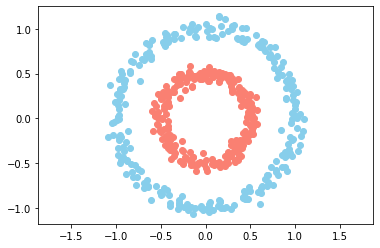

In [63]:
# Crear el dataset

n = 500
p = 2

x, y = make_circles(n_samples=n, factor=0.5, noise=0.05)
y = y[:, np.newaxis]

plt.scatter(x[y[:,0] == 0, 0], x[y[:,0] == 0, 1], c="skyblue")
plt.scatter(x[y[:,0] == 1, 0], x[y[:,0] == 1, 1], c="salmon")
plt.axis("equal")
plt.show()

In [14]:
# Clase de la capa de la red

class neural_layer():
  def __init__(self, n_conn, n_neur, act_f):
    self.act_f = act_f
    self.b = np.random.rand(1, n_neur)*2 - 1
    self.w = np.random.rand(n_conn, n_neur)*2 - 1

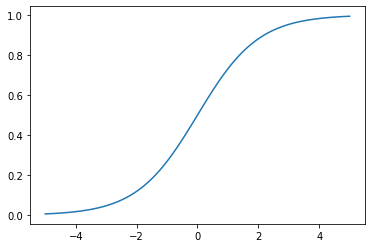

In [64]:
# Funciones de activacion

sigm = (lambda x: 1 / (1 + np.e**(-x)),
        lambda x: x * (1 - x))

relu = lambda x: np.maximum(0, x)

_x = np.linspace(-5, 5, 100)
plt.plot(_x, sigm[0](_x))


In [65]:


def create_nn(topology, act_f):
  nn = []
  for l, layer in enumerate(topology[:-1]):
    nn.append(neural_layer(topology[l], topology[l+1], act_f))
  return nn


  


In [84]:
topology = [p, 4, 8, 1]

neural_net = create_nn(topology, sigm)

l2_cost = (lambda yp, yr: np.mean((yp - yr)**2),
           lambda yp, yr: (yp - yr))


def train(neural_net, x, y, l2_cost, lr=0.5, train=True):
  out = [(None, x)]

  # Forward pass
  for l, layer in enumerate(neural_net):

    z = out[-1][1] @ neural_net[l].w + neural_net[l].b
    a = neural_net[l].act_f[0](z)

    out.append((z, a))

  print(l2_cost[0](out[-1][1], y))

  if train:

    #Backward pass
    deltas = []

    for l in reversed(range(0, len(neural_net))):

      z = out[l+1][0]
      a = out[l+1][1]

      if l == len(neural_net) - 1:
        #Calcular detla ultima capa.
        deltas.insert(0, l2_cost[1](a, y) * neural_net[l].act_f[1](a))
      else:
        #Calcular delta respecto a la capa previa 
        deltas.insert(0, deltas[0] @ _w.T * neural_net[l].act_f[1](a))
        
      _w = neural_net[l].w

      #Gradient descent
      neural_net[l].b = neural_net[l].b - np.mean(deltas[0], axis=0, keepdims=True)*lr
      #print(out[1][1].T.shape, deltas[0].shape)
      neural_net[l].w = neural_net[l].w - out[l][1].T @ deltas[0]*lr

  return out[-1][1]

        


#train(neural_net, x, y, l2_cost, 0.5)
#print("")

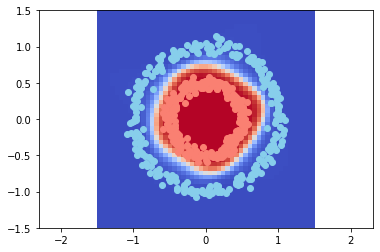

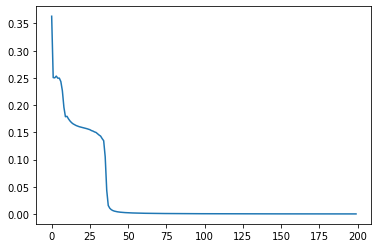

0.0002138650175196423
0.00021380984897325755
0.00021375470769694637
0.00021369959367080626
0.00021364450687495507
0.00021358944728952907
0.0002135344148946836
0.0002134794096705942
0.00021342443159745445
0.00021336948065547726
0.0002133145568248951
0.00021325966008595948
0.00021320479041893968
0.00021314994780412616
0.00021309513222182619
0.00021304034365236788
0.00021298558207609718
0.00021293084747337908
0.0002128761398245976
0.00021282145911015576
0.00021276680531047597
0.00021271217840599803
0.00021265757837718165
0.00021260300520450508


In [85]:
import time
from IPython.display import clear_output

neural_n = create_nn(topology, sigm)

loss = []

for i in range(5000):
  #Entrenemos a la red!

  py = train(neural_n, x, y, l2_cost, lr=0.05)

  if i % 25 == 0:
    loss.append(l2_cost[0](py, y))

    res = 50

    _x0 = np.linspace(-1.5, 1.5, res)
    _x1 = np.linspace(-1.5, 1.5, res)

    _y = np.zeros((res, res))

    for i0, x0 in enumerate(_x0):
      for i1, x1 in enumerate(_x1):
        _y[i0, i1] = train(neural_n, np.array([[x0, x1]]), y, l2_cost, train=False)[0][0]
    
    plt.pcolormesh(_x0, _x1, _y, cmap="coolwarm")
    plt.axis("equal")

    plt.scatter(x[y[:,0] == 0, 0], x[y[:,0] == 0, 1], c="skyblue")
    plt.scatter(x[y[:,0] == 1, 0], x[y[:,0] == 1, 1], c="salmon")

    clear_output(wait=True)
    plt.show()
    plt.plot(range(len(loss)), loss)
    plt.show()
    time.sleep(0.5)
